In [12]:
import mido
from mido import MidiFile
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt 
import pychord


In [13]:
# # Open the MIDI file
# mid = MidiFile(Path('midi files', 'mix.mid'))
# #key is metadata? there's a simple function for it
# #return key and notes (transposed to c major) per quarter note as an array

# # Initialize time accumulator
# absolute_time = 0

# # Iterate through tracks and messages
# for track in mid.tracks:
#     absolute_time = 0
#     for msg in track:
#         # Accumulate delta time to get absolute time
#         absolute_time += msg.time
        
#         # Check for note messages
#         if msg.type == 'note_on' and msg.velocity > 0:
#             print(f'Note On: {msg.note} at time: {absolute_time}')
#         elif msg.type == 'note_off' or (msg.type == 'note_on' and msg.velocity == 0):
#             print(f'Note Off: {msg.note} at time: {absolute_time}')

In [14]:
def unpack_midi(midi_filename):
    """ 
    arguments: path to a midi file
    returns: four matrices S, A, T, B of dimension (num_pitches) x (num quarter notes) containing note info for each part
    #also return a vector for each of base chord (e.g. B not B7) over time
    """

    #load in the file
    mid = MidiFile(Path('midi files', midi_filename+'.mid'))

    #get parameters
    meta_track = mid.tracks[0] #grab the track that stores the metadata
    for msg in meta_track:
        #grab the tempo
        if msg.type == 'set_tempo': 
            tempo = msg.tempo
        elif msg.type == 'time_signature':
            numerator = msg.numerator
            denominator = msg.denominator

        #is there anything else we want from this? apparently key signature will sometimes be here    

    PPQ = mid.ticks_per_beat #get PPQ (samples per quarter note)

    length_sec = mid.length #length of the track in seconds
    
    length_ticks = mido.second2tick(length_sec, PPQ, tempo) #turns the length of the file in seconds to the length of the file in ticks?

    #calculate the number of beats
    num_beats = int(length_ticks / PPQ)

    metadata = [tempo, PPQ, length_ticks]
    #initialize list of output arrays
    #assumes will be returned in SATB order
    list_of_parts = []
    
    #unpack each vocal part
    for i in range(1, len(mid.tracks)): #loop over all non-metadata tracks
        track = mid.tracks[i] #index into the right part of the midi file (one indexed)

        #frequency is hardcoded to 4 times per quarter note
        list_of_parts.append(get_piano_roll(track, PPQ, 4, num_beats))

    return list_of_parts, metadata

In [15]:
#used AI for this. Really struggled to implement it on my own. I feel good about how much I understand it though
def get_piano_roll(track, PPQ, freq, num_beats, plot=False):
    total_samples = freq * num_beats
    output_array = np.zeros((128, total_samples))
    
    # Track the "start time" of currently active notes
    # stores {note_number: start_sample_index}
    open_notes = {}
    absolute_tick = 0

    for msg in track:
        absolute_tick += msg.time
        
        # Convert absolute MIDI ticks to our matrix column index
        current_sample = int((absolute_tick * freq) / PPQ)

        is_note_on = (msg.type == 'note_on' and msg.velocity > 0)
        is_note_off = (msg.type == 'note_off' or (msg.type == 'note_on' and msg.velocity == 0))

        if is_note_on:
            # If the note was already "on", close it first (prevents stuck notes)
            if msg.note not in open_notes:
                open_notes[msg.note] = current_sample
                
        elif is_note_off:
            if msg.note in open_notes:
                start_sample = open_notes.pop(msg.note)
                end_sample = current_sample
                
                # Fill the duration of the note
                if end_sample > start_sample:
                    output_array[msg.note, start_sample:end_sample] = 1
        
        if current_sample >= total_samples:
            break

    # if a note was never turned off, extend it to the end
    for note, start_sample in open_notes.items():
        output_array[note, start_sample:] = 1

    if plot:
        plt.figure(figsize=(12, 6))
        plt.imshow(output_array, aspect='auto', origin='lower', cmap='gray_r')
        plt.xlabel('Time (Samples)')
        plt.ylabel('MIDI Pitch')
        plt.show()
        
    return output_array

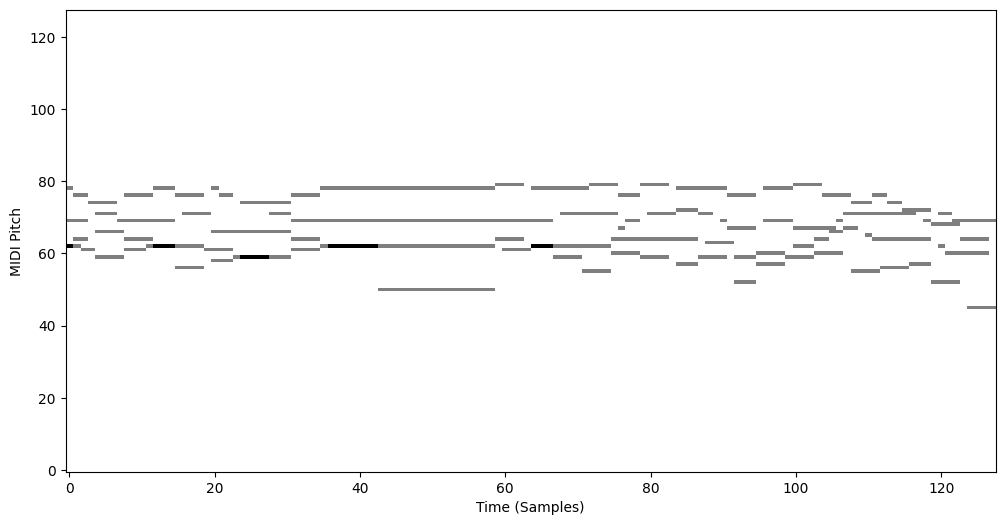

In [16]:
[S, A, T, B], metadata = unpack_midi('mix')
roll = S+A+T+B

plt.figure(figsize=(12, 6))
plt.imshow(roll, aspect='auto', origin='lower', cmap='gray_r')
plt.xlabel('Time (Samples)')
plt.ylabel('MIDI Pitch')
plt.show()

In [57]:
roots = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

In [ ]:
def index_to_note(midi_index, roots=['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']):
    names = roots
    return f"{names[midi_index % 12]}"


def roll_to_chord(roll):
    """ arguments: takes a piano roll matrix 
    returns a tuple of chords and indices
    """

    pitches, samples = roll.shape
    output = []

    for i in range(samples):
        indices = np.nonzero(roll[:, i])[0] #this returns a tuple of an array, the first thing is the stuff we want

        notes = []
        for j in range(len(indices)): #for each midi index, turn that into a note
            notes.append(index_to_note(indices[j]))

        #turn the notes into a chord
        chord = pychord.analyzer.find_chords_from_notes(notes) #can have it just return the notes
        output.append((i, chord)) #return the chord with its timestamp

    return output

In [23]:
chords = roll_to_chord(roll)
print(chords)
print(type(chords[0]))
print(type(chords[0][0]))
print(type(chords[0][1]))


#looks like it doesn't always give us a well defined chord. Might have to find moments when they hold?

[(0, []), (1, []), (2, []), (3, []), (4, []), (5, []), (6, []), (7, []), (8, []), (9, []), (10, []), (11, []), (12, []), (13, []), (14, []), (15, []), (16, []), (17, []), (18, []), (19, []), (20, []), (21, []), (22, []), (23, [<Chord: B5>]), (24, []), (25, []), (26, []), (27, []), (28, []), (29, []), (30, []), (31, []), (32, []), (33, []), (34, []), (35, []), (36, []), (37, []), (38, []), (39, []), (40, []), (41, []), (42, []), (43, []), (44, []), (45, []), (46, []), (47, []), (48, []), (49, []), (50, []), (51, []), (52, []), (53, []), (54, []), (55, []), (56, []), (57, []), (58, []), (59, []), (60, []), (61, []), (62, []), (63, [<Chord: Ano5/C#>]), (64, []), (65, []), (66, []), (67, [<Chord: Bm>]), (68, []), (69, []), (70, []), (71, []), (72, []), (73, []), (74, []), (75, []), (76, []), (77, []), (78, []), (79, [<Chord: Em/B>]), (80, []), (81, []), (82, []), (83, [<Chord: E5>]), (84, []), (85, []), (86, []), (87, []), (88, []), (89, [<Chord: B>]), (90, []), (91, []), (92, []), (93, []

In [19]:
notes = ['D', 'A', 'F#']
print(pychord.analyzer.find_chords_from_notes(notes))
#it returns blank stuff sometimes

[]


In [20]:
def big_parent_function(filename):
    [S, A, T, B], metadata = unpack_midi(filename)

    chords = roll_to_chord(S+A+T+B)

    #TODO get consistent chord information from SATB information
    #TODO shift to normalize chords



In [55]:
# def chordToIdxDict(key, C=14):
#     """
#     Input:
#         - key: string specifying key (eg "Cmaj", "Dmin")
#         - C: number of unique chords in key signatures
#     Output:
#         - dictionary mapping 14 key strings to their index 
#     """
#     chordDict = {}
#     for idx in range(int(C/2)):
#         major_chord = pychord.Chord.from_note_index(idx+1, "", key)
#         minor_chord = pychord.Chord.from_note_index(idx+1, "m", key)

#         chordDict[str(major_chord)] = 2*idx
#         chordDict[str(minor_chord)] = 2*idx+1
#     return chordDict

def getRootToIdxDict(roots = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']):
    """
    Input:
        - roots: list specifying potential chord roots, with each root represented as a string
                      (e.g. 'A' or 'C#)
        - C: number of unique chords in key signatures
    Output:
        - root_to_idx: dictionary mapping chord root to its index
    """
    root_to_idx = {r: i for i, r in enumerate(roots)}
    # alias enharmonic spellings (flats + theoretical E#/B#/Cb/Fb) to a canonical index
    enharmonic_aliases = {
        'Db': 'C#', 'Eb': 'D#', 'Gb': 'F#', 'Ab': 'G#', 'Bb': 'A#',
        'E#': 'F',  'B#': 'C',  'Cb': 'B',  'Fb': 'E',
    }
    for alias, canonical in enharmonic_aliases.items():
        root_to_idx[alias] = root_to_idx[canonical]
    return root_to_idx

In [58]:
dict = getRootToIdxDict(roots)
print(dict)
# minor_chord = pychord.Chord.from_note_index(3.5, "m", "Cmin")
minor_chord = pychord.Chord.from_note_index(4, "", "Dmaj")
print(minor_chord)


{'C': 0, 'C#': 1, 'D': 2, 'D#': 3, 'E': 4, 'F': 5, 'F#': 6, 'G': 7, 'G#': 8, 'A': 9, 'A#': 10, 'B': 11, 'Db': 1, 'Eb': 3, 'Gb': 6, 'Ab': 8, 'Bb': 10, 'E#': 5, 'B#': 0, 'Cb': 11, 'Fb': 4}
G


example of "chords"
[]
[(0, []), (1, []), (2, []), (3, []), (4, []), (5, []), (6, []), (7, []), (8, []), (9, []), (10, []), (11, []), (12, []), (13, []), (14, []), (15, []), (16, []), (17, []), (18, []), (19, []), (20, []), (21, []), (22, []), (23, [<Chord: B5>]), (24, []), (25, []), (26, []), (27, []), (28, []), (29, []), (30, []), (31, []), (32, []), (33, []), (34, []), (35, []), (36, []), (37, []), (38, []), (39, []), (40, []), (41, []), (42, []), (43, []), (44, []), (45, []), (46, []), (47, []), (48, []), (49, []), (50, []), (51, []), (52, []), (53, []), (54, []), (55, []), (56, []), (57, []), (58, []), (59, []), (60, []), (61, []), (62, []), (63, [<Chord: Ano5/C#>]), (64, []), (65, []), (66, []), (67, [<Chord: Bm>]), (68, []), (69, []), (70, []), (71, []), (72, []), (73, []), (74, []), (75, []), (76, []), (77, []), (78, []), (79, [<Chord: Em/B>]), (80, []), (81, []), (82, []), (83, [<Chord: E5>]), (84, []), (85, []), (86, []), (87, []), (88, []), (89, [<Chord: B>]), (90, []), (91, []), (92, []), (93, []), (94, []), (95, [<Chord: Am(no5)>]), (96, []), (97, []), (98, []), (99, []), (100, []), (101, []), (102, []), (103, []), (104, []), (105, []), (106, []), (107, [<Chord: Em/G>]), (108, []), (109, [<Chord: G>]), (110, []), (111, []), (112, []), (113, []), (114, []), (115, []), (116, []), (117, []), (118, []), (119, [<Chord: Eno5>]), (120, []), (121, []), (122, []), (123, [<Chord: Am/C>]), (124, []), (125, []), (126, []), (127, [])]


In [45]:
def getChordRoll(chords, chordToIdxDict=dict, C=24):
    """
    Inputs:
        - chords: List (sampDur x 2) of tuples of the form (sample, [<Chord: X>]) (with dtypes (int, ChordO))
        - chordToIdxDict: dictionary mapping {chord_identifier:index(int)}
        - C: number of chord options
    Outputs:
        - chord_roll: (C x sampDur) matrix specifying the activated chord(s) at each time sample
    """
    sampDur = len(chords)
    chord_roll = np.zeros((C, sampDur))

    for (samp, chord_list) in chords:
        for chord in chord_list:
            chord_idx = chordToIdxDict[str(chord.root)]
            chord_roll[chord_idx, samp] = 1
    
    return chord_roll

In [46]:
chord_roll = getChordRoll(chords)

plt.imshow(chord_roll)

KeyError: 'B'